# Phase 3 - Per-Regime Fair-Value Regression

Predicts the **fair value of the CL c1-c2 calendar spread** from regime drivers, one model per effective regime.

Design (locked):
- **Prescribed family** (no per-cell beauty contest): baseline **OLS** -> **Ridge** -> **Elastic-Net**.
- **Per-regime fit on the wildcard pattern** (`H|*|Flat` trains on all H-inventory Flat days), so every regime has enough data.
- **Partial pooling**: each regime's coefficients are blended toward the global model, weighted by sample size (`w = n/(n+K)`), so thin regimes borrow strength.
- **Walk-forward (TimeSeriesSplit)** out-of-sample scoring.
- **Beat-the-baseline gate**: a regime keeps its pooled model only if it beats global OLS OOS by a margin; else it **falls back to OLS**.

Leakage guard: the spread (`cal_1_2`, `slope_*`) and curve-shape PCs are **excluded** from features - drivers are fundamentals/state/seasonal/level only.

Output: `cache/CL_fairvalue.parquet` (actual, fair_value, residual per day) for Phase 4.

In [1]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, RidgeCV, ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
pd.set_option("display.max_columns", 60)

CACHE = Path("cache"); INSTRUMENT = "CL"
K_POOL  = 100      # pooling strength: w = n/(n+K)
MARGIN  = 0.02     # regime model must cut OOS RMSE by >=2% vs OLS baseline
N_SPLITS= 5

reg = pd.read_parquet(CACHE / f"{INSTRUMENT}_regimes.parquet").sort_index()

# leakage-safe driver set (NO cal_1_2 / slope / curve-shape PCs)
FEATURES = ["eia_crude_stocks_seas_z","eia_cushing_stocks_seas_z","rv_c1","vix","dxy","dgs10","t10yie",
            "dtwexbgs","seas_sin","seas_cos","days_to_expiry","pc_level"]
TARGET = "cal_1_2"
reg = reg.dropna(subset=[TARGET])
print("rows:", len(reg), "| features:", len(FEATURES))

train_m = (reg["split"]=="train").values
# fit imputer+scaler on TRAIN only (point-in-time)
imp = SimpleImputer(strategy="median").fit(reg.loc[train_m, FEATURES])
scl = StandardScaler().fit(imp.transform(reg.loc[train_m, FEATURES]))
X = scl.transform(imp.transform(reg[FEATURES]))
y = reg[TARGET].values
regime = reg["regime_eff"].values
inv, vol, curve = reg["inv"].values, reg["vol"].values, reg["curve"].values
train_pos = np.where(train_m)[0]; test_pos = np.where(~train_m)[0]
print("train", len(train_pos), "test", len(test_pos))

rows: 1408 | features: 12
train 1339 test 69


## 1. Helpers: wildcard pattern, model factory, pooled fit/predict

In [2]:
def pattern_mask(key):
    a = key.split("|")
    m = np.ones(len(reg), dtype=bool)
    if a[0] != "*": m &= (inv == a[0])
    if a[1] != "*": m &= (vol == a[1])
    if a[2] != "*": m &= (curve == a[2])
    return m

# choose alphas once on full train (global)
ridge_cv = RidgeCV(alphas=np.logspace(-3,3,25)).fit(X[train_pos], y[train_pos])
enet_cv  = ElasticNetCV(l1_ratio=[.2,.5,.7,.9], alphas=np.logspace(-3,1,25),
                        cv=5, max_iter=10000).fit(X[train_pos], y[train_pos])
RIDGE_A = ridge_cv.alpha_; ENET_A, ENET_L1 = enet_cv.alpha_, enet_cv.l1_ratio_
print(f"ridge alpha={RIDGE_A:.4g} | enet alpha={ENET_A:.4g} l1={ENET_L1}")

def make(family):
    if family=="ols":   return LinearRegression()
    if family=="ridge": return Ridge(alpha=RIDGE_A)
    if family=="enet":  return ElasticNet(alpha=ENET_A, l1_ratio=ENET_L1, max_iter=10000)

def pooled_predict(tr_pos, pred_pos, family, K=K_POOL):
    """Fit global + per-regime (wildcard) on tr_pos, blend by size, predict pred_pos."""
    gm = make(family).fit(X[tr_pos], y[tr_pos])
    out = pd.Series(gm.predict(X[pred_pos]), index=pred_pos)   # global default
    if K == 0:                       # K=0 => pure global (used for OLS baseline)
        return out
    for key in np.unique(regime[pred_pos]):
        pm = pattern_mask(key)
        rtr = tr_pos[pm[tr_pos]]
        if len(rtr) < 20:            # too few even on the pattern -> keep global
            continue
        rm = make(family).fit(X[rtr], y[rtr])
        w = len(rtr)/(len(rtr)+K)
        coef = w*rm.coef_ + (1-w)*gm.coef_
        icpt = w*rm.intercept_ + (1-w)*gm.intercept_
        pp = pred_pos[regime[pred_pos]==key]
        out.loc[pp] = X[pp] @ coef + icpt
    return out

ridge alpha=10 | enet alpha=0.4642 l1=0.2


## 2. Walk-forward CV on train: baseline vs pooled Ridge vs pooled Elastic-Net

In [3]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
oos = {f: pd.Series(index=train_pos, dtype=float) for f in ["base","ridge","enet"]}
for tr_idx, va_idx in tscv.split(train_pos):
    tr, va = train_pos[tr_idx], train_pos[va_idx]
    oos["base"].loc[va]  = pooled_predict(tr, va, "ols", K=0).values
    oos["ridge"].loc[va] = pooled_predict(tr, va, "ridge").values
    oos["enet"].loc[va]  = pooled_predict(tr, va, "enet").values

oos = pd.DataFrame(oos).dropna()
ya = pd.Series(y, index=range(len(y))).loc[oos.index]
def rmse(a,b): return np.sqrt(mean_squared_error(a,b))
overall = {f: rmse(ya, oos[f]) for f in oos}
print("CV OOS RMSE:", {k: round(v,4) for k,v in overall.items()})
CHOSEN = "ridge" if overall["ridge"] <= overall["enet"] else "enet"
print("chosen pooled family:", CHOSEN)

CV OOS RMSE: {'base': np.float64(1.2618), 'ridge': np.float64(0.7034), 'enet': np.float64(0.668)}
chosen pooled family: enet


## 3. Per-regime gate: keep pooled model only if it beats OLS by the margin

In [4]:
rkey = pd.Series(regime, index=range(len(regime))).loc[oos.index]
rows = []
keep = {}
for key, idx in oos.groupby(rkey).groups.items():
    a = ya.loc[idx]; n=len(idx)
    rb = rmse(a, oos["base"].loc[idx]); rc = rmse(a, oos[CHOSEN].loc[idx])
    kept = rc < rb*(1-MARGIN)
    keep[key] = kept
    rows.append((key, n, round(rb,4), round(rc,4),
                 f"{(rb-rc)/rb*100:+.1f}%", "pooled "+CHOSEN if kept else "OLS fallback"))
gate = pd.DataFrame(rows, columns=["regime","n_oos","rmse_OLS","rmse_pooled","improve","decision"]
                   ).sort_values("n_oos", ascending=False)
print("kept pooled:", sum(keep.values()), "/", len(keep))
gate

kept pooled: 14 / 15


,regime,n_oos,rmse_OLS,rmse_pooled,improve,decision
13,M|L|Back,161,0.8608,0.4112,+52.2%,pooled enet
8,L|L|Back,148,0.9516,0.4797,+49.6%,pooled enet
9,L|M|Back,129,1.3234,0.4786,+63.8%,pooled enet
6,L|*|Flat,78,1.0473,0.6287,+40.0%,pooled enet
5,H|M|Flat,73,1.7097,0.8176,+52.2%,pooled enet
14,M|M|Flat,70,1.6473,0.9562,+42.0%,pooled enet
3,H|L|Back,67,1.1327,0.3781,+66.6%,pooled enet
4,H|L|Flat,63,1.4598,0.7958,+45.5%,pooled enet
12,M|H|Back,61,1.1063,0.6599,+40.4%,pooled enet
1,H|*|Back,60,2.0739,0.7969,+61.6%,pooled enet


## 4. Final fit on full train, predict test, score

In [5]:
# fair value for ALL rows: pooled CHOSEN for kept regimes, OLS baseline for fallbacks
fv_pooled = pooled_predict(train_pos, np.arange(len(reg)), CHOSEN)
fv_base   = pooled_predict(train_pos, np.arange(len(reg)), "ols", K=0)
fair = fv_base.copy()
for key, kept in keep.items():
    if kept:
        m = regime==key
        fair.loc[np.where(m)[0]] = fv_pooled.loc[np.where(m)[0]]
fair = fair.sort_index()

reg = reg.assign(fair_value=fair.values, residual=(y - fair.values))
te = reg["split"]=="test"
print("TEST  RMSE pooled-final:", round(np.sqrt(mean_squared_error(y[test_pos], fair.loc[test_pos])),4),
      "| R2:", round(r2_score(y[test_pos], fair.loc[test_pos]),3))
print("TEST  RMSE OLS-baseline:", round(np.sqrt(mean_squared_error(y[test_pos], fv_base.loc[test_pos])),4),
      "| R2:", round(r2_score(y[test_pos], fv_base.loc[test_pos]),3))
# per-regime test metrics
tr_rows=[]
for key, idx in reg[te].groupby("regime_eff").groups.items():
    yy=reg.loc[idx, TARGET]; ff=reg.loc[idx,"fair_value"]
    if len(idx)>=3:
        tr_rows.append((key,len(idx),round(np.sqrt(mean_squared_error(yy,ff)),4),round(r2_score(yy,ff),3)))
pd.DataFrame(tr_rows, columns=["regime","n_test","test_rmse","test_r2"]).sort_values("n_test",ascending=False)

TEST  RMSE pooled-final: 4.794 | R2: -1.324
TEST  RMSE OLS-baseline: 4.7331 | R2: -1.266


,regime,n_test,test_rmse,test_r2
0,H|*|Back,44,5.8375,-2.319
1,M|H|Back,24,1.8972,-1.311


## 5. Save fair value + residuals (feeds Phase 4) and per-regime residual std

In [6]:
# residual std per regime on TRAIN (for Phase 4 z-scoring)
res_std = reg[reg.split=="train"].groupby("regime_eff")["residual"].std().rename("resid_std_train")
reg = reg.join(res_std, on="regime_eff")

keep_df = pd.Series(keep, name="kept_pooled")
out = CACHE / f"{INSTRUMENT}_fairvalue.parquet"
cols = ["cal_1_2","fair_value","residual","resid_std_train","regime_eff","regime_level",
        "near_boundary","boundary_dist","split"]
reg[cols].to_parquet(out)
pd.Series({"chosen_family":CHOSEN,"ridge_alpha":RIDGE_A,"enet_alpha":ENET_A,
           "enet_l1":ENET_L1,"K_pool":K_POOL,"margin":MARGIN}).to_json(CACHE/"CL_model_meta.json")
print("saved:", out)
print("kept pooled regimes:", list(keep_df[keep_df].index))
reg[cols].tail(4)

saved: cache\CL_fairvalue.parquet
kept pooled regimes: ['H|*|*', 'H|*|Back', 'H|*|Flat', 'H|L|Back', 'H|L|Flat', 'H|M|Flat', 'L|*|Flat', 'L|L|Back', 'L|M|Back', 'M|*|Back', 'M|*|Flat', 'M|H|Back', 'M|L|Back', 'M|M|Flat']


,cal_1_2,fair_value,residual,resid_std_train,regime_eff,regime_level,near_boundary,boundary_dist,split
date,,,,,,,,,
2026-05-19,4.279000,0.897182,3.381818,0.391955,H|*|Back,1,False,0.082871,test
2026-05-20,4.202500,1.075062,3.127438,0.665116,M|H|Back,0,False,0.132110,test
2026-05-21,3.250833,1.058968,2.191865,0.665116,M|H|Back,0,False,0.182204,test
2026-05-22,3.346667,1.085189,2.261478,0.665116,M|H|Back,0,False,0.231526,test


## 6. Sanity: fair value vs actual, residuals

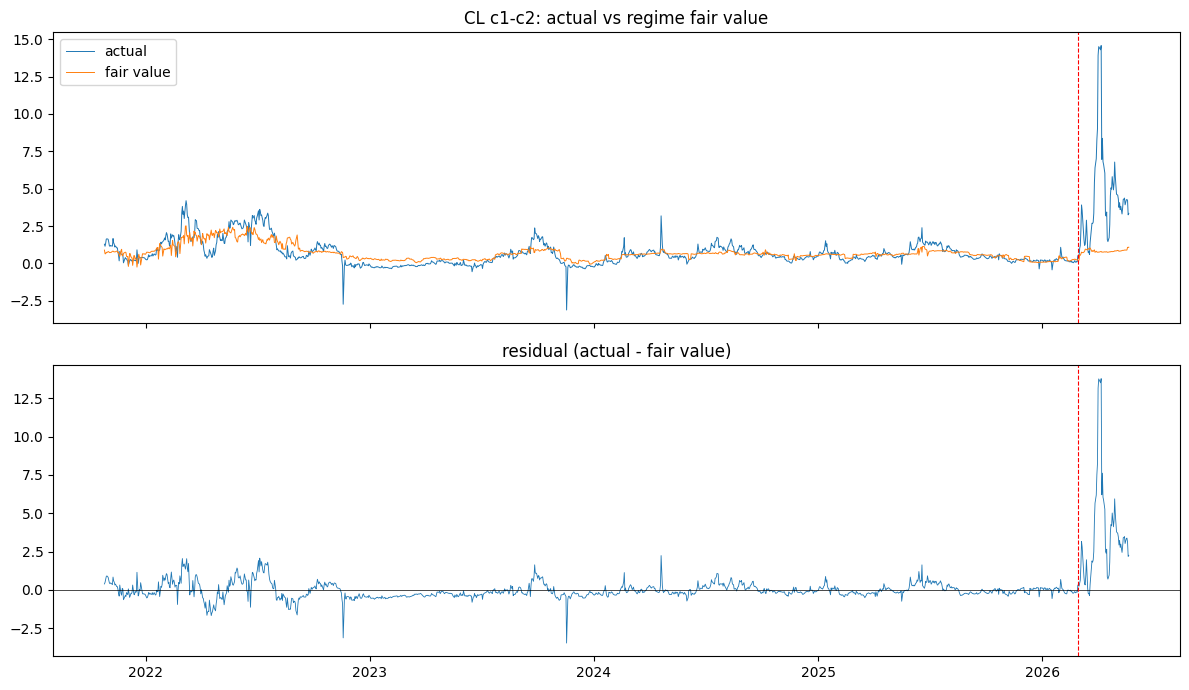

        count   mean    std   min    25%    50%    75%     max
split                                                         
test     69.0  3.610  3.178 -0.37  1.812  3.031  4.509  13.780
train  1339.0 -0.033  0.491 -3.46 -0.300 -0.120  0.157   2.244


In [7]:
fig, ax = plt.subplots(2,1, figsize=(12,7), sharex=True)
ax[0].plot(reg.index, reg["cal_1_2"], lw=.7, label="actual")
ax[0].plot(reg.index, reg["fair_value"], lw=.7, label="fair value")
ax[0].axvline(pd.Timestamp("2026-03-01"), color="r", ls="--", lw=.8)
ax[0].legend(); ax[0].set_title("CL c1-c2: actual vs regime fair value")
ax[1].plot(reg.index, reg["residual"], lw=.6); ax[1].axhline(0,color="k",lw=.5)
ax[1].axvline(pd.Timestamp("2026-03-01"), color="r", ls="--", lw=.8)
ax[1].set_title("residual (actual - fair value)")
plt.tight_layout(); plt.show()
print(reg.groupby("split")["residual"].describe().round(3))